# Feature Engineering — W3

**목적**: 세션별 feature 계산 → 부스터 가중치 데이터 근거 확보  
**데이터**: Retailrocket (10% 샘플)  
**결과물**: `outputs/` PNG 3종 + `session_features.csv`

---

## 결론 요약 (분석 후 업데이트)

| 부스터 | 대응 Feature | 현재 가중치 | 권장 가중치 |
|---|---|---|---|
| session_length_5min | is_long_session | 0.25 | - |
| hidden_repeated | item_revisit_count | 0.1 | - |
| clipboard_copy_match | (데이터 없음) | 0.4 | 유지 |
| broadcast_channel_multi_tab | (데이터 없음) | 0.4 | 유지 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'font.size': 12,
    'axes.titlesize': 14,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False
})
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로딩 + 세션 분리

In [2]:
events_full = pd.read_csv('data/events.csv')
sample_visitors = events_full['visitorid'].drop_duplicates().sample(frac=0.1, random_state=42)
events = events_full[events_full['visitorid'].isin(sample_visitors)].copy()
print(f'샘플: {len(events):,}행')

SESSION_GAP_MS = 30 * 60 * 1000
events = events.sort_values(['visitorid', 'timestamp']).reset_index(drop=True)
events['time_diff'] = events.groupby('visitorid')['timestamp'].diff()
events['new_session'] = (events['time_diff'] > SESSION_GAP_MS) | events['time_diff'].isna()
events['session_num'] = events.groupby('visitorid')['new_session'].cumsum()
events['session_id'] = events['visitorid'].astype(str) + '_' + events['session_num'].astype(str)
print(f'세션 수: {events["session_id"].nunique():,}')

샘플: 274,415행
세션 수: 176,661


## 2. Feature 계산 (8개)

In [3]:
base = events.groupby('session_id').agg(
    start_ts=('timestamp', 'min'),
    end_ts=('timestamp', 'max'),
    event_count=('event', 'count'),
    view_count=('event', lambda x: (x == 'view').sum()),
    cart_count=('event', lambda x: (x == 'addtocart').sum()),
).reset_index()
base['session_duration_sec'] = (base['end_ts'] - base['start_ts']) / 1000
base['is_long_session'] = base['session_duration_sec'] >= 300

item_revisit = (
    events[events['event'] == 'view']
    .groupby('session_id')
    .apply(lambda x: (x.groupby('itemid').size() > 1).sum())
    .reset_index(name='item_revisit_count')
)

avg_interval = events.groupby('session_id')['time_diff'].mean().reset_index()
avg_interval.columns = ['session_id', 'avg_event_interval_ms']
avg_interval['avg_event_interval_sec'] = avg_interval['avg_event_interval_ms'] / 1000

txn_sids = set(events[events['event'] == 'transaction']['session_id'])
base['has_purchase'] = base['session_id'].isin(txn_sids)

features = base.merge(item_revisit, on='session_id', how='left')
features = features.merge(avg_interval[['session_id', 'avg_event_interval_sec']], on='session_id', how='left')
features = features.fillna(0)

FEATURES = ['session_duration_sec', 'event_count', 'view_count',
            'cart_count', 'item_revisit_count', 'avg_event_interval_sec']

print(f'Feature 계산 완료: {len(features):,}개 세션')
print(f'구매 세션 비율: {features["has_purchase"].mean()*100:.2f}%')
print()
print(features[FEATURES + ['has_purchase']].describe().round(2))

Feature 계산 완료: 176,661개 세션
구매 세션 비율: 0.75%

       session_duration_sec  event_count  view_count  cart_count  \
count             176661.00    176661.00   176661.00   176661.00   
mean                 104.55         1.55        1.50        0.04   
std                  466.65         2.37        2.09        0.47   
min                    0.00         1.00        0.00        0.00   
25%                    0.00         1.00        1.00        0.00   
50%                    0.00         1.00        1.00        0.00   
75%                    0.00         1.00        1.00        0.00   
max                32799.21       219.00      170.00       91.00   

       item_revisit_count  avg_event_interval_sec  
count           176661.00               176661.00  
mean                 0.14               140888.54  
std                  0.50               718953.82  
min                  0.00                    0.00  
25%                  0.00                    0.00  
50%                  0.00      

## 3. Feature별 구매율

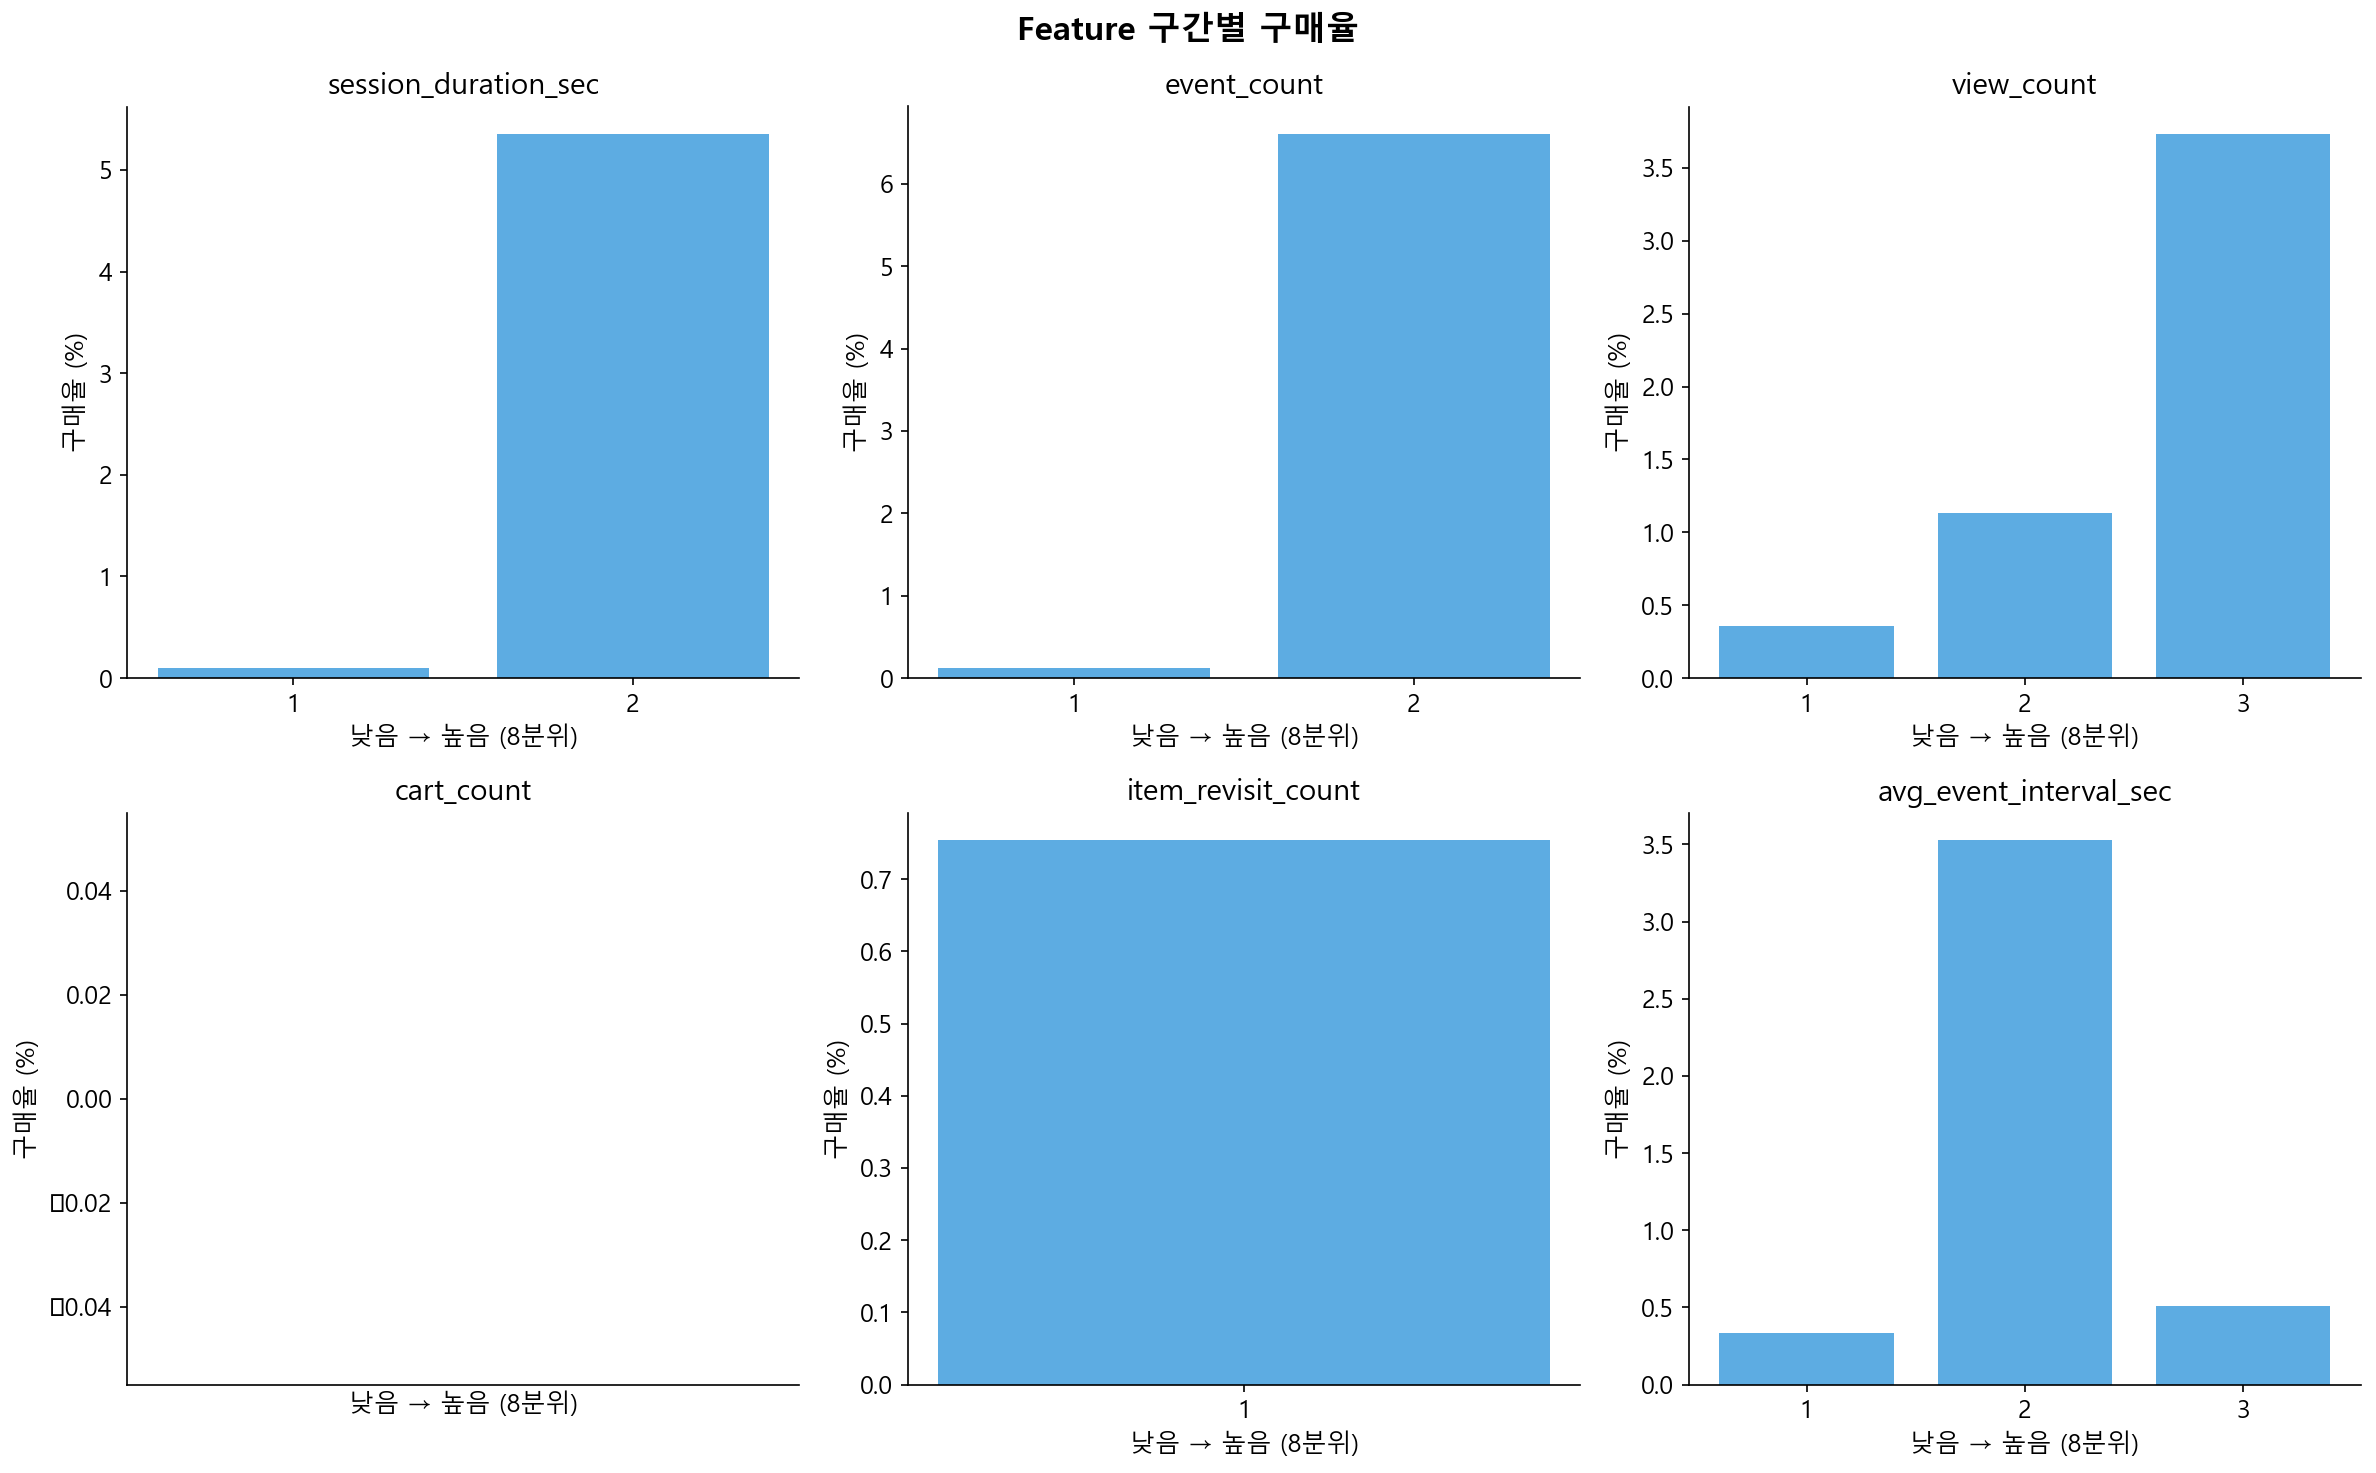

저장: outputs/feature_purchase_rate.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    temp = features[[feat, 'has_purchase']].copy()
    temp['bin'] = pd.qcut(temp[feat].clip(upper=temp[feat].quantile(0.95)), q=8, duplicates='drop')
    grouped = temp.groupby('bin', observed=True)['has_purchase'].mean() * 100
    ax.bar(range(len(grouped)), grouped.values, color='#3498db', alpha=0.8)
    ax.set_title(feat)
    ax.set_ylabel('구매율 (%)')
    ax.set_xlabel('낮음 → 높음 (8분위)')
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(j+1) for j in range(len(grouped))])

plt.suptitle('Feature 구간별 구매율', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/feature_purchase_rate.png', bbox_inches='tight')
plt.show()
print('저장: outputs/feature_purchase_rate.png')

## 4. 상관관계 히트맵

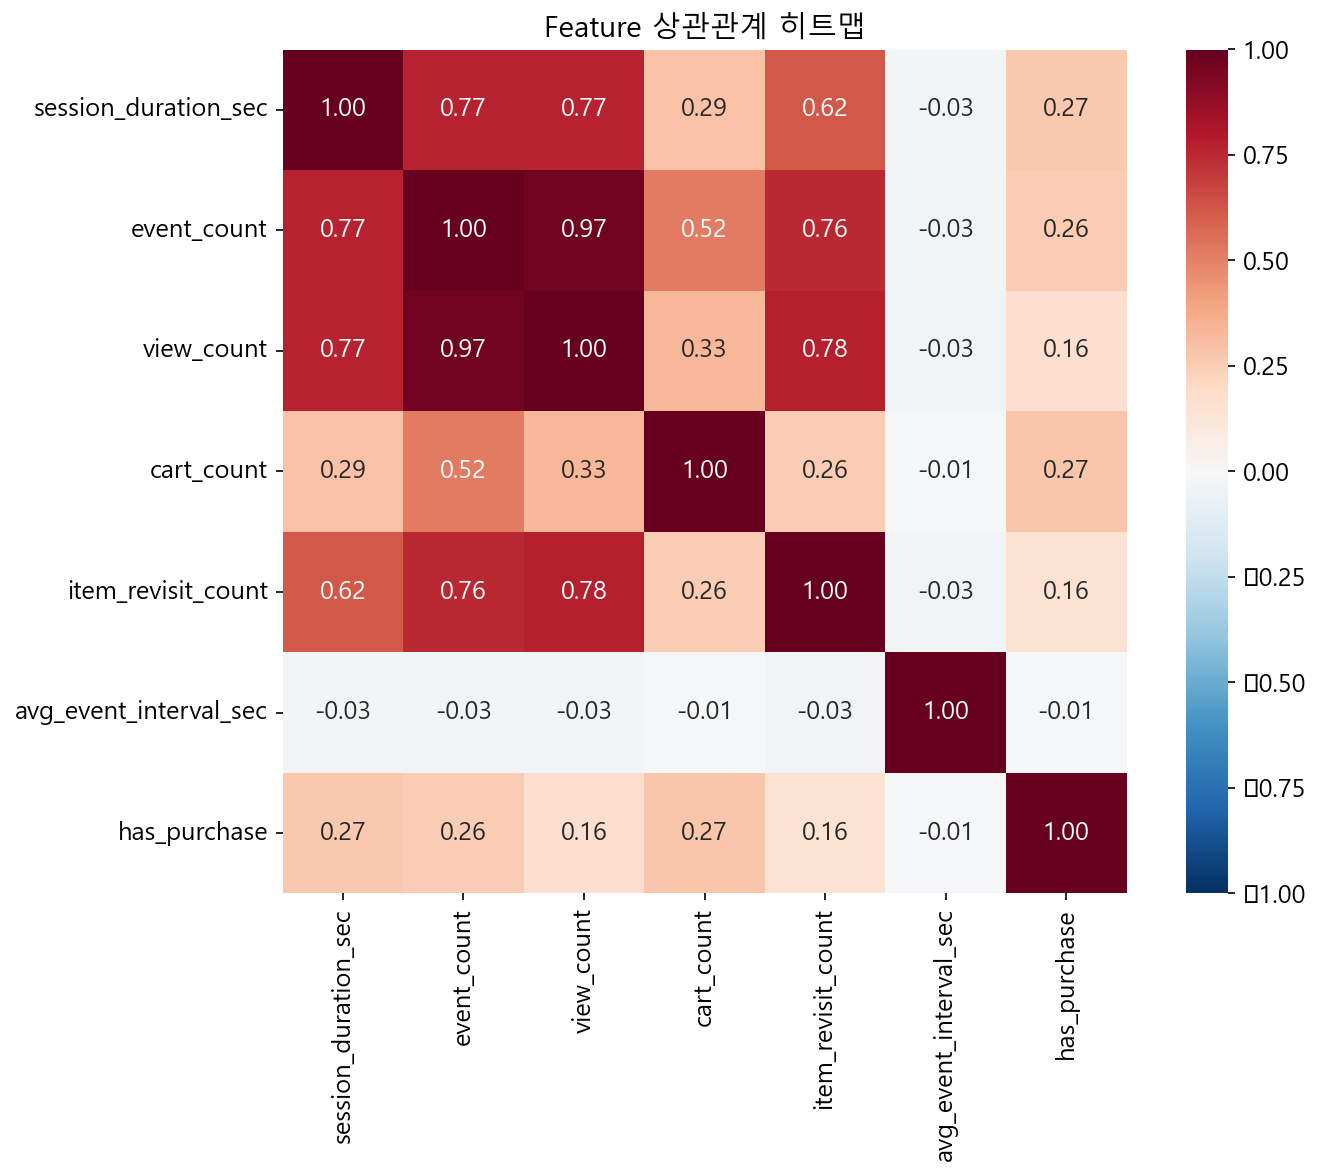

저장: outputs/feature_correlation.png

has_purchase 상관계수 (절댓값 내림차순):
cart_count                0.275
session_duration_sec      0.271
event_count               0.256
view_count                0.164
item_revisit_count        0.155
avg_event_interval_sec    0.013
Name: has_purchase, dtype: float64


In [5]:
corr = features[FEATURES + ['has_purchase']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature 상관관계 히트맵')
plt.tight_layout()
plt.savefig('outputs/feature_correlation.png', bbox_inches='tight')
plt.show()
print('저장: outputs/feature_correlation.png')
print()
print('has_purchase 상관계수 (절댓값 내림차순):')
print(corr['has_purchase'].drop('has_purchase').abs().sort_values(ascending=False).round(3))

## 5. 부스터 가중치 권장값 산출

In [6]:
long_v  = features[features['is_long_session'] == True]['has_purchase'].mean() * 100
short_v = features[features['is_long_session'] == False]['has_purchase'].mean() * 100
lift_long = long_v / short_v

revisit_v    = features[features['item_revisit_count'] > 0]['has_purchase'].mean() * 100
no_revisit_v = features[features['item_revisit_count'] == 0]['has_purchase'].mean() * 100
lift_revisit = revisit_v / no_revisit_v

w_long    = round(min(0.1 * lift_long, 0.4), 2)
w_revisit = round(min(0.1 * lift_revisit, 0.4), 2)

print('=' * 50)
print('Feature Engineering 결론')
print('=' * 50)
print(f'[session_length_5min]  lift={lift_long:.2f}x  권장 가중치={w_long}')
print(f'[hidden_repeated]      lift={lift_revisit:.2f}x  권장 가중치={w_revisit}')
print('[clipboard_copy]       데이터 없음 → 0.4 유지')
print('[broadcast_channel]    데이터 없음 → 0.4 유지')

Feature Engineering 결론
[session_length_5min]  lift=32.19x  권장 가중치=0.4
[hidden_repeated]      lift=8.76x  권장 가중치=0.4
[clipboard_copy]       데이터 없음 → 0.4 유지
[broadcast_channel]    데이터 없음 → 0.4 유지


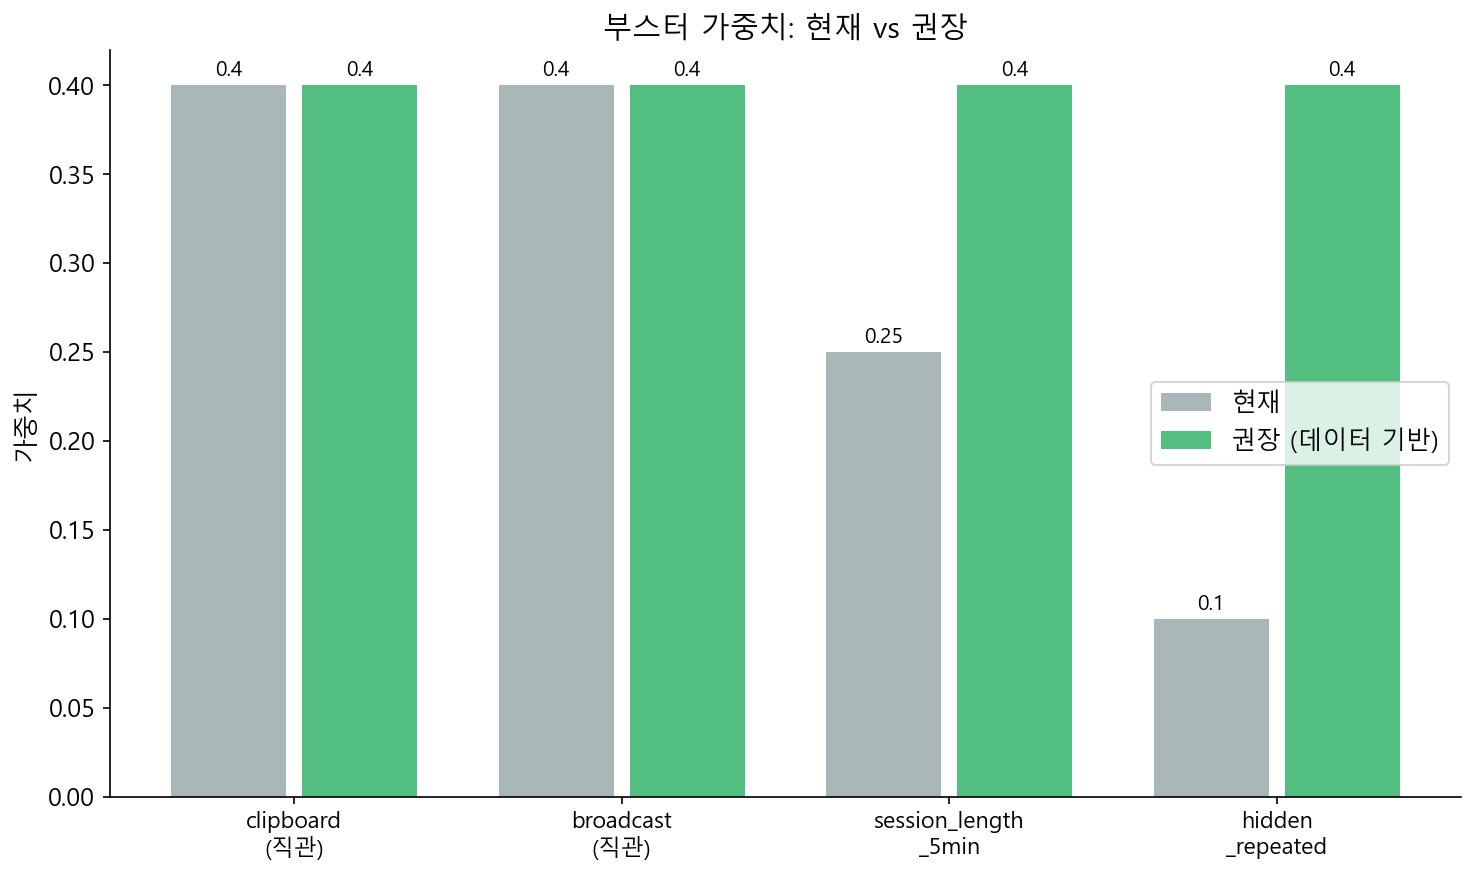

저장: outputs/booster_weights.png


In [7]:
boosters    = ['clipboard\n(직관)', 'broadcast\n(직관)', 'session_length\n_5min', 'hidden\n_repeated']
current     = [0.4, 0.4, 0.25, 0.1]
recommended = [0.4, 0.4, w_long, w_revisit]

x = np.arange(len(boosters))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 0.2, current,     0.35, label='현재',            color='#95a5a6', alpha=0.8)
ax.bar(x + 0.2, recommended, 0.35, label='권장 (데이터 기반)', color='#27ae60', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(boosters, fontsize=11)
ax.set_ylabel('가중치')
ax.set_title('부스터 가중치: 현재 vs 권장')
ax.legend()
for xi, (c, r) in zip(x, zip(current, recommended)):
    ax.text(xi - 0.2, c + 0.005, str(c), ha='center', fontsize=10)
    ax.text(xi + 0.2, r + 0.005, str(r), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/booster_weights.png', bbox_inches='tight')
plt.show()
print('저장: outputs/booster_weights.png')

In [8]:
save_cols = ['session_id'] + FEATURES + ['is_long_session', 'has_purchase']
features[save_cols].to_csv('outputs/session_features.csv', index=False)
print(f'저장: outputs/session_features.csv ({len(features):,}행)')

저장: outputs/session_features.csv (176,661행)
